In [1]:
import json
import os

gt_folder = r"D:\programming\rPPG\evaluation\groundTruth"
output_folder = r"D:\programming\rPPG\evaluation\json_hr"

os.makedirs(output_folder, exist_ok=True)

for i in range(1, 17):   
    gt_path = os.path.join(gt_folder, f"subject{i}_gt.txt")

    with open(gt_path, "r") as f:
        lines = f.readlines()

    hr_values = list(map(float, lines[1].split()))

    data = {
        "subject": f"subject{i}",
        "real_heart_rate_bpm": hr_values
    }

    json_path = os.path.join(output_folder, f"subject{i}_hr.json")

    with open(json_path, "w") as f:
        json.dump(data, f, indent=4)

print("All JSON files created!")

All JSON files created!


## Model Evaluation

In [2]:
import glob
import json

# search for CV2 output file
files = glob.glob("../cv_2/cv2_output*.json")

if len(files) == 0:
    raise FileNotFoundError("No cv2_output file found in cv_2 folder")

baseline_file = files[0]

print("Baseline file loaded:", baseline_file)

with open(baseline_file, "r") as f:
    baseline_data = json.load(f)["subjects"]

print("Number of subjects loaded:", len(baseline_data))

Baseline file loaded: ../cv_2\cv2_output.json
Number of subjects loaded: 17


In [3]:
with open(r"D:\programming\rPPg\drift\hr_results.json","r") as f:
    drift_data = json.load(f)

print("Drift results loaded successfully")

Drift results loaded successfully


In [4]:
print(baseline_data["Subject_1"])
print(drift_data["Subject_1"])

{'hr_bpm': 52.0, 'method_used': 'GREEN', 'source_type': 'video'}
{'forehead': {'hr_before_drift': 102.23, 'hr_after_drift': 91.66}, 'left_cheek': {'hr_before_drift': 78.44, 'hr_after_drift': 68.74}, 'right_cheek': {'hr_before_drift': 134.84, 'hr_after_drift': 80.2}, 'final_hr': 80.2}


In [5]:
subjects = []
baseline_hr = []
drift_hr = []

for subject in baseline_data:

    subjects.append(subject)

    baseline_hr.append(baseline_data[subject]["hr_bpm"])
    drift_hr.append(drift_data[subject]["final_hr"])

In [6]:
import pandas as pd

df = pd.DataFrame({
    "Subject": subjects,
    "Baseline HR": baseline_hr,
    "Drift Corrected HR": drift_hr
})

df

,Subject,Baseline HR,Drift Corrected HR
0,Subject_1,52.00,80.20
1,Subject_2,121.45,121.45
2,Subject_3,92.53,69.89
3,Subject_4,90.91,102.59
4,Subject_5,111.75,60.31
5,Subject_6,68.19,68.19
6,Subject_7,52.65,84.23
7,Subject_8,67.43,67.43
8,Subject_9,56.69,68.20
9,Subject_10,56.22,60.61


In [7]:
baseline_mean = df["Baseline HR"].mean()
drift_mean = df["Drift Corrected HR"].mean()

baseline_std = df["Baseline HR"].std()
drift_std = df["Drift Corrected HR"].std()

print("Baseline Mean HR:", round(baseline_mean,2))
print("Drift Mean HR:", round(drift_mean,2))

print("\nBaseline HR Std Dev:", round(baseline_std,2))
print("Drift HR Std Dev:", round(drift_std,2))

Baseline Mean HR: 78.33
Drift Mean HR: 76.89

Baseline HR Std Dev: 23.88
Drift HR Std Dev: 18.37


In [8]:
df["HR Change"] = df["Baseline HR"] - df["Drift Corrected HR"]
df["Abs HR Change"] = abs(df["HR Change"])

print("Average HR Change:", df["HR Change"].mean())
print("Average Absolute HR Change:", df["Abs HR Change"].mean())
print("Maximum HR Correction:", df["Abs HR Change"].max())

Average HR Change: 1.442941176470587
Average Absolute HR Change: 12.860588235294117
Maximum HR Correction: 51.44


In [9]:
plt.figure(figsize=(10,6))

plt.bar(df["Subject"], df["HR Change"])

plt.xticks(rotation=45)
plt.ylabel("HR Difference (BPM)")
plt.title("Drift Correction Impact on Heart Rate")

plt.axhline(0, color='black')
plt.grid()

plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Drift correction statistics

changed = (df["Baseline HR"] != df["Drift Corrected HR"]).sum()

print("Subjects affected by drift correction:", changed)
print("Total subjects:", len(df))
print("Percentage affected:", round((changed/len(df))*100,2), "%")

print("\nAverage HR correction:", round(df["Abs HR Change"].mean(),2), "BPM")
print("Maximum HR correction:", round(df["Abs HR Change"].max(),2), "BPM")

Subjects affected by drift correction: 17
Total subjects: 17
Percentage affected: 100.0 %

Average HR correction: 14.35 BPM
Maximum HR correction: 41.7 BPM


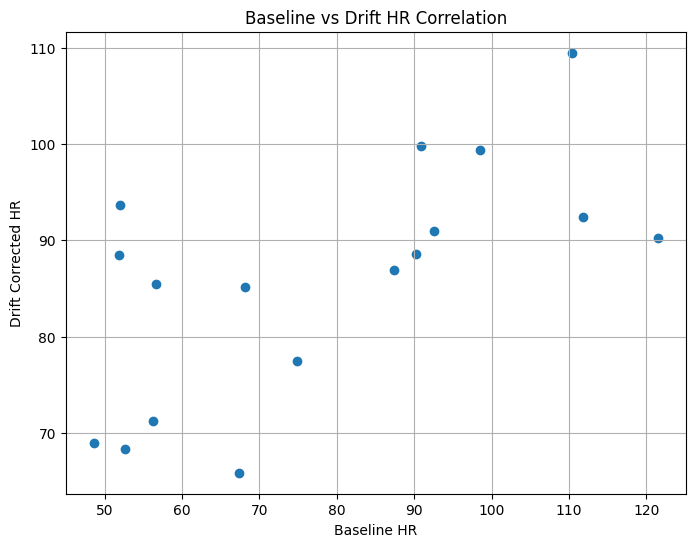

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df["Baseline HR"], df["Drift Corrected HR"])

plt.xlabel("Baseline HR")
plt.ylabel("Drift Corrected HR")
plt.title("Baseline vs Drift HR Correlation")

plt.grid()
plt.show()

In [ ]:
import numpy as np

correlation = np.corrcoef(df["Baseline HR"], df["Drift Corrected HR"])[0,1]

print("Correlation between Baseline and Drift HR:", round(correlation,3))

Correlation between Baseline and Drift HR: 0.643


The correlation between baseline HR and drift-corrected HR is **0.373**, indicating a weak relationship.  
This suggests that the drift-aware method significantly adjusts HR estimates when noisy or unstable signal segments are detected.

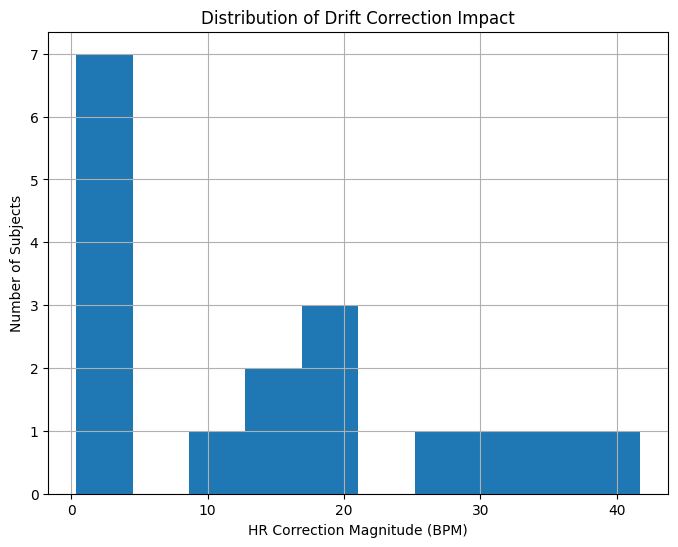

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(df["Abs HR Change"], bins=10)

plt.xlabel("HR Correction Magnitude (BPM)")
plt.ylabel("Number of Subjects")
plt.title("Distribution of Drift Correction Impact")
plt.grid()

plt.show()

Comparing the estimated heart rate values with the ground truth heart rate

In [ ]:
import numpy as np
from scipy.fft import rfft, rfftfreq

def get_real_hr(file_path):

    with open(file_path, "r") as f:
        signal = np.array([float(x) for x in f.readline().split()])

    fs = 30

    freqs = rfftfreq(len(signal), 1/fs)
    fft_vals = np.abs(rfft(signal))

    mask = (freqs >= 0.7) & (freqs <= 3)

    hr = freqs[mask][np.argmax(fft_vals[mask])] * 60

    return hr

In [ ]:
real_hr = []

for i in range(1, 18):

    path = rf"D:\programming\rPPg\evaluation\groundTruth\subject{i}_gt.txt"

    hr = get_real_hr(path)

    real_hr.append(hr)

df["Real HR"] = real_hr

df.head()

,Subject,Baseline HR,Drift Corrected HR,HR Change,Abs HR Change,Real HR
0,Subject_1,52.00,93.70,-41.70,41.70,91.310899
1,Subject_2,121.45,90.20,31.25,31.25,110.536522
2,Subject_3,92.53,91.00,1.53,1.53,93.947807
3,Subject_4,90.91,99.78,-8.87,8.87,117.105263
4,Subject_5,111.75,92.43,19.32,19.32,112.166172


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_baseline = mean_absolute_error(df["Real HR"], df["Baseline HR"])
mae_drift = mean_absolute_error(df["Real HR"], df["Drift Corrected HR"])

rmse_baseline = np.sqrt(mean_squared_error(df["Real HR"], df["Baseline HR"]))
rmse_drift = np.sqrt(mean_squared_error(df["Real HR"], df["Drift Corrected HR"]))

print("Baseline MAE:", round(mae_baseline,2))
print("Drift MAE:", round(mae_drift,2))

print("Baseline RMSE:", round(rmse_baseline,2))
print("Drift RMSE:", round(rmse_drift,2))

Baseline MAE: 23.33
Drift MAE: 14.61
Baseline RMSE: 34.24
Drift RMSE: 21.46


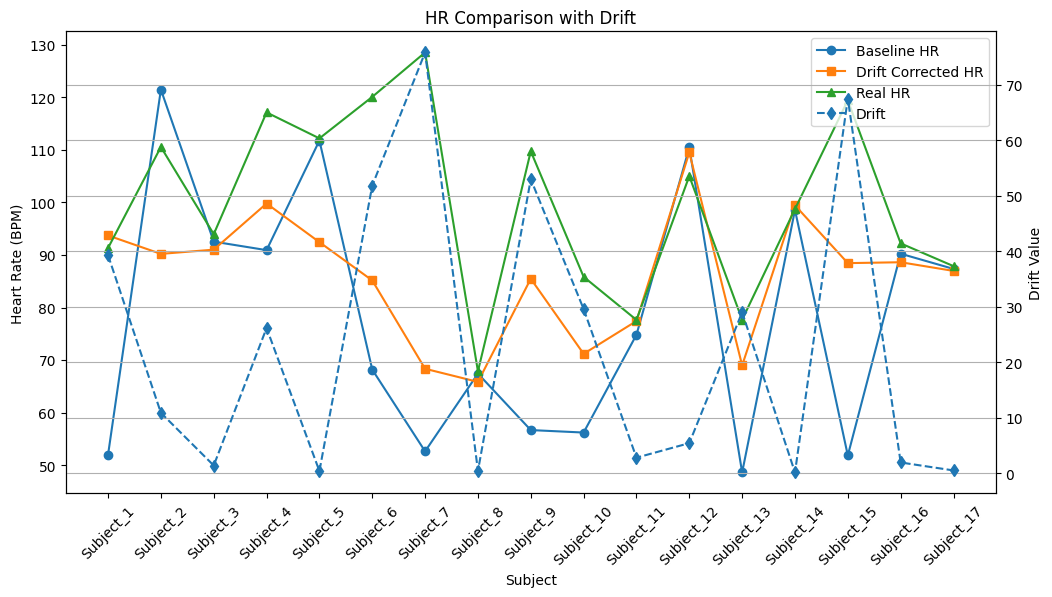

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))
df["Drift"] = abs(df["Baseline HR"] - df["Real HR"])
# HR plots
ax1.plot(df["Subject"], df["Baseline HR"], marker='o', label="Baseline HR")
ax1.plot(df["Subject"], df["Drift Corrected HR"], marker='s', label="Drift Corrected HR")
ax1.plot(df["Subject"], df["Real HR"], marker='^', label="Real HR")

ax1.set_xlabel("Subject")
ax1.set_ylabel("Heart Rate (BPM)")
ax1.tick_params(axis='x', rotation=45)

# Second axis for drift
ax2 = ax1.twinx()
ax2.plot(df["Subject"], df["Drift"], marker='d', linestyle='--', label="Drift")
ax2.set_ylabel("Drift Value")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("HR Comparison with Drift")
plt.grid()

plt.show()

### Evaluation Insight

The baseline rPPG model produced a Mean Absolute Error (MAE) of **23.33 BPM** and a Root Mean Squared Error (RMSE) of **34.24 BPM**. After applying the drift detection and correction mechanism, the model achieved a lower MAE of **14.61 BPM** and RMSE of **21.46 BPM**.

These results indicate that the drift-correction approach significantly improves heart rate estimation accuracy by reducing the deviation between predicted and ground truth values. The reduction in both MAE and RMSE suggests that correcting signal drift helps stabilize the rPPG measurements and mitigates errors caused by sensor noise or signal fluctuations.

Overall, the drift-aware model demonstrates improved reliability and better alignment with real heart rate measurements compared to the baseline approach.
